In [1]:
import sys
sys.path.append("..")
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from numbers import Number
from qiskit.synthesis import LieTrotter
import numpy as np
import scipy as scipy

### State preparation with 1 ancilla and 2 excitations on a total of 35 qubits

In [137]:
def prep_psi_0(qc: QuantumCircuit):
    qc.cx(34, 10)
    qc.cx(34, 31)
    return qc


def prep_psi_0_by_0(qc: QuantumCircuit):
    qc.cx(34, 10, ctrl_state="0")
    qc.cx(34, 31, ctrl_state="0")
    return qc

### Test if state prep works as expected

In [138]:
from qiskit_aer import StatevectorSimulator
from qiskit_aer.primitives import SamplerV2

# sv = StatevectorSimulator()
sampler = SamplerV2(options={"backend_options": {"method": "matrix_product_state"}})
qc = QuantumCircuit(35)
qc.h(34)
qc = prep_psi_0(qc)
qc.measure_all()

job = sampler.run([qc])
res = job.result()

res[0].data.meas.get_counts()

{'00000000000000000000000000000000000': 486,
 '10010000000000000000000010000000000': 538}

In [139]:
qc = QuantumCircuit(35)
qc.h(34)
qc = prep_psi_0(qc)
qc = prep_psi_0_by_0(qc)
qc.measure_all()
job = sampler.run([qc])
res = job.result()

res[0].data.meas.get_counts()

{'00010000000000000000000010000000000': 540,
 '10010000000000000000000010000000000': 484}

## Hardware experiments

In [5]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(name='algolab')
backend= service.backend('ibm_torino')

In [6]:
from qiskit.quantum_info import Pauli

def Heisenberg(J, n, ent_map, h=0, mag=False):
    if isinstance(J, Number):
        J = np.ones(len(ent_map)) * J
    else:
        assert len(J) == len(ent_map)
    String = "I" * n
    H = SparsePauliOp("I" * n, 0)
    for j, c in zip(J, ent_map):
        c = np.sort(c)
        XX = String[: c[0]] + "X" + String[c[0] + 1 : c[1]] + "X" + String[c[1] + 1 :]
        H += SparsePauliOp(XX, j)
        YY = String[: c[0]] + "Y" + String[c[0] + 1 : c[1]] + "Y" + String[c[1] + 1 :]
        H += SparsePauliOp(YY, j)
        ZZ = String[: c[0]] + "Z" + String[c[0] + 1 : c[1]] + "Z" + String[c[1] + 1 :]
        H += SparsePauliOp(ZZ, j)
    if mag:
        for i in range(n):
            z_string = Pauli("I"*n)
            z_string[i] = "Z"
            H+= h*SparsePauliOp(z_string)        
    return H.chop()

In [7]:
from qiskit.transpiler import generate_preset_pass_manager


t_steps = 8
num_qubits = 34
circuits = np.ndarray([t_steps, t_steps], dtype=QuantumCircuit)
H_tilde = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde = np.zeros([t_steps, t_steps], dtype=complex)
delta_t = np.pi / 40
synth = LieTrotter(reps=1)

qubit_subset = (
    list(range(42, 48))
    + [35]
    + list(range(25, 30))
    + [36, 48, 49, 50, 54]
    + list(range(61, 66))
    + list(range(66, 70))
    + [56, 73, 82, 83, 84, 85, 86, 74]
)


cm = backend.coupling_map
reduced_map = cm.reduce(qubit_subset)
edge_list = {(a, b) if a < b else (b, a) for a, b in list(reduced_map.get_edges())}


def Heisenberg(J, n, ent_map, h=0):
    if isinstance(J, Number):
        J = np.ones(len(ent_map)) * J
    else:
        assert len(J) == len(ent_map)
    String = "I" * n
    H = SparsePauliOp("I" * n, 0)
    for j, c in zip(J, ent_map):
        c = np.sort(c)
        XX = String[: c[0]] + "X" + String[c[0] + 1 : c[1]] + "X" + String[c[1] + 1 :]
        H += SparsePauliOp(XX, j)
        YY = String[: c[0]] + "Y" + String[c[0] + 1 : c[1]] + "Y" + String[c[1] + 1 :]
        H += SparsePauliOp(YY, j)
        ZZ = String[: c[0]] + "Z" + String[c[0] + 1 : c[1]] + "Z" + String[c[1] + 1 :]
        H += SparsePauliOp(ZZ, j)     
    return H.chop()


H = Heisenberg(1, num_qubits, edge_list)

# Generate approximate time evolution, rather than using PauliEvolutionGate
Rxyz_circ = QuantumCircuit(2)
Rxyz_circ.rxx(2 * delta_t, 0, 1)
Rxyz_circ.ryy(2 * delta_t, 0, 1)
Rxyz_circ.rzz(2 * delta_t, 0, 1)
Rxyz_instr = Rxyz_circ.to_instruction(label="RXX+YY+ZZ")
qc_temp = QuantumCircuit(num_qubits)
for edge in edge_list:
    qc_temp.append(Rxyz_instr, edge)
time_evol = QuantumCircuit(num_qubits).compose(qc_temp)

# time_evol=PauliEvolutionGate(H,time=delta_t,synthesis=synth)
real_obs_H = SparsePauliOp("X", 1) ^ H
imag_obs_H = SparsePauliOp("Y", 1) ^ H
real_obs_S = SparsePauliOp("X", 1) ^ SparsePauliOp("I" * 34, 1)
imag_obs_S = SparsePauliOp("Y", 1) ^ SparsePauliOp("I" * 34, 1)


for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(35)
        qc.h(34)
        qc = prep_psi_0(qc)
        for _ in range(n):
            qc.append(time_evol, range(34))
        qc = prep_psi_0_by_0(qc)
        for _ in range(m):
            qc.append(time_evol, range(34))
        circuits[i][j] = qc.copy()

init_layout = qubit_subset + [55]  # ancilla at qubit 55 on torino
pm = generate_preset_pass_manager(
    backend=backend, optimization_level=3, initial_layout=init_layout
)

circs = []
for i in range(t_steps):
    circs.append([])
    for j in range(t_steps):
        if circuits[i][j] is not None:
            circs[i].append(circuits[i][j])
        else:
            circs[i].append(circuits[j][i])

circs = [pm.run(circ) for circ in circs]

print(
    f"Max circuit depth:{max([circs[i][j].depth(lambda x: len(x.qubits)==2) for i in range(t_steps) for j in range(t_steps)])}"
)

Max circuit depth:73


In [10]:
def truncation(threshold, S):
    eigvals, eigvecs = np.linalg.eig(S)
    idx = eigvals.argsort()[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    D = len(eigvals)
    truncated_eigvals = []
    truncated_eigvecs = []
    # make truncated matrix whose rows are eigenvectors of S with eigval above threshold
    for i in range(D):
        if eigvals[i] >= threshold:
            truncated_eigvals.append(eigvals[i])
            truncated_eigvecs.append(eigvecs[i])
    truncated_eigvals = np.array(truncated_eigvals)
    truncated_eigvecs = np.array(truncated_eigvecs).T
    print(len(truncated_eigvals))
    return truncated_eigvecs


def E_vs_D(H_tilde, S_tilde, threshold_slope):
    GSEs = []
    ground_states = []
    for d in range(1, len(S_tilde)+1):
        epsilon = threshold_slope
        H_temp = H_tilde[0:d, 0:d]
        S_temp = S_tilde[0:d, 0:d]
        V_eps = truncation(epsilon, S_temp)
        # solve GEVP
        A = V_eps.conj().T @ H_temp @ V_eps
        B = V_eps.conj().T @ S_temp @ V_eps
        E, c = scipy.linalg.eig(a=A, b=B)
        idx = E.argsort()[::-1]
        eigvals = E[idx]
        eigvecs = c[:, idx]
        GSEs.append(eigvals[-1])
        ground_states.append(eigvecs[:, -1])
        print(min(eigvals))

    return GSEs, ground_states, V_eps

## Run on (a noisy) simulator for comparison

In [290]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2
# from qiskit_ibm_runtime import EstimatorV2
from qiskit_aer.noise import NoiseModel
from qiskit import transpile
from qiskit.synthesis import LieTrotter, SuzukiTrotter
from qiskit_ibm_runtime.fake_provider import FakeTorino
from tqdm.notebook import tqdm

#step_size=20

step_size=30

def prep_psi_0(qc: QuantumCircuit):
    qc.cx(34, 10)
    qc.cx(34, 31)
    return qc


def prep_psi_0_by_0(qc: QuantumCircuit):
    qc.cx(34, 10, ctrl_state="0")
    qc.cx(34, 31, ctrl_state="0")
    return qc

t_steps = 18
n_qubits = 34  # number of data qubits
circuits = np.ndarray([t_steps, t_steps], dtype=QuantumCircuit)
H_tilde_sim_noisy = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde_sim_noisy= np.zeros([t_steps, t_steps], dtype=complex)

delta_t = np.pi / step_size
#synth = LieTrotter(reps=1)
synth = SuzukiTrotter(reps=3)
#num_shots = 800000
num_shots=1e28

H = Heisenberg(1, n_qubits, edge_list)

basis_gates = backend.basis_gates


# initialize noisy simulator

simulator = EstimatorV2(
    options={
        "backend_options": {"method": "matrix_product_state"},
        "default_precision": 1 / np.sqrt(num_shots),
    }
)

# pm = generate_preset_pass_manager(backend=sim_backend, optimization_level=3)
# Rxyz_circ = QuantumCircuit(2)
# Rxyz_circ.rxx(2 * delta_t, 0, 1)
# Rxyz_circ.ryy(2 * delta_t, 0, 1)
# Rxyz_circ.rzz(2 * delta_t, 0, 1)
# Rxyz_instr = Rxyz_circ.to_instruction(label="RXX+YY+ZZ")
# qc_temp = QuantumCircuit(n_qubits)
# for edge in edge_list:
#     qc_temp.append(Rxyz_instr, edge)
# time_evol = QuantumCircuit(n_qubits).compose(qc_temp)


time_evol = PauliEvolutionGate(H, time=delta_t, synthesis=synth)

real_obs_H = SparsePauliOp("X", 1) ^ H
imag_obs_H = SparsePauliOp("Y", 1) ^ H
real_obs_S = SparsePauliOp("X", 1) ^ SparsePauliOp("I" * n_qubits, 1)
imag_obs_S = SparsePauliOp("Y", 1) ^ SparsePauliOp("I" * n_qubits, 1)


for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(35)
        qc.h(34)
        qc = prep_psi_0(qc)
        for _ in range(n):
            qc.append(time_evol, range(34))
        qc = prep_psi_0_by_0(qc)
        for _ in range(m):
            qc.append(time_evol, range(34))
        circuits[i][j] = transpile(qc.copy().decompose(reps=1), basis_gates=basis_gates)



with tqdm(total=t_steps*t_steps) as pbar:
    for i in range(t_steps):
        for j in range(t_steps):
            if circuits[i][j] is not None:
                circ = circuits[i][j]
                layout = circ.layout
                obs=[real_obs_H, imag_obs_H,
                          real_obs_S, imag_obs_S]
                sim_job = simulator.run(
                [
                    (
                        circ, obs
                    )
                ]
                )
                H_tilde_sim_noisy[i, j] = (
                    sim_job.result()[0].data.evs[0] + 1j * sim_job.result()[0].data.evs[1]
                )
                S_tilde_sim_noisy[i, j] = (
                    sim_job.result()[0].data.evs[2] + 1j * sim_job.result()[0].data.evs[3]
                )
            else:
                circ = circuits[j][i]
                layout = circ.layout
                obs=[real_obs_H.apply_layout(layout), imag_obs_H.apply_layout(layout),
                          real_obs_S.apply_layout(layout), imag_obs_S.apply_layout(layout)]
                sim_job = simulator.run(
                [
                    (
                        circ,obs
                    )
                ]
                )
                H_tilde_sim_noisy[i, j] = (
                sim_job.result()[0].data.evs[0] - 1j * sim_job.result()[0].data.evs[1]
                )
                S_tilde_sim_noisy[i, j] = (
                sim_job.result()[0].data.evs[2] - 1j * sim_job.result()[0].data.evs[3]
                )
            pbar.update(1)

        

  0%|          | 0/324 [00:00<?, ?it/s]

1
(24.00000000000018-3.373454130481685e-14j)
2
(20.130097029748136+1.311217004223088e-14j)
3
(18.61597937807979-1.670802701115661e-12j)
4
(18.235104257666872-1.3903689978187244e-12j)
5
(18.083676691108977+5.6514644919440357e-11j)
6
(18.033563750783546+7.355960726914127e-10j)
7
(18.00885504800502+9.00134060389787e-09j)
8
(17.992395362948717+1.4333177130169402e-07j)
8
(17.995211648453644-1.5479221585173115e-09j)
9
(17.98268094066503-1.9129826900217048e-08j)
9
(17.97969706648729+2.4110243704449062e-08j)
10
(17.955271468502442+6.518023701062675e-08j)
10
(17.976082315407282-2.2695620512371922e-08j)
10
(17.97398746548186+1.978080885058246e-09j)
11
(17.929214796709427+5.581668836200067e-08j)
11
(17.93311532872884-6.105285685908336e-09j)
12
(17.927305248194806+3.762704215981303e-08j)
12
(17.91104249437808+8.912599301237193e-10j)


/var/folders/6p/67gfm43s19b12128lxx6vlzm0000gn/T/ipykernel_86262/1313742520.py:29: RuntimeWarning: divide by zero encountered in matmul
  A = V_eps.conj().T @ H_temp @ V_eps
/var/folders/6p/67gfm43s19b12128lxx6vlzm0000gn/T/ipykernel_86262/1313742520.py:29: RuntimeWarning: overflow encountered in matmul
  A = V_eps.conj().T @ H_temp @ V_eps
/var/folders/6p/67gfm43s19b12128lxx6vlzm0000gn/T/ipykernel_86262/1313742520.py:29: RuntimeWarning: invalid value encountered in matmul
  A = V_eps.conj().T @ H_temp @ V_eps
/var/folders/6p/67gfm43s19b12128lxx6vlzm0000gn/T/ipykernel_86262/1313742520.py:30: RuntimeWarning: divide by zero encountered in matmul
  B = V_eps.conj().T @ S_temp @ V_eps
/var/folders/6p/67gfm43s19b12128lxx6vlzm0000gn/T/ipykernel_86262/1313742520.py:30: RuntimeWarning: overflow encountered in matmul
  B = V_eps.conj().T @ S_temp @ V_eps
/var/folders/6p/67gfm43s19b12128lxx6vlzm0000gn/T/ipykernel_86262/1313742520.py:30: RuntimeWarning: invalid value encountered in matmul
  B = V_

Text(0, 0.5, 'Ground state energy')

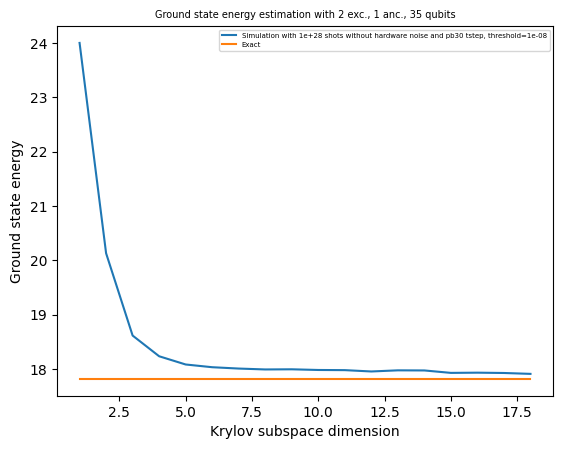

In [318]:
import matplotlib.pyplot as plt

#threshold = 1/15
# threshold = 1e-14
threshold = 1e-8
GSEs_sim_noisy,g_state,_ = E_vs_D(H_tilde_sim_noisy, S_tilde_sim_noisy,threshold)

plt.plot(
    list(range(1, t_steps + 1)),
         GSEs_sim_noisy,
    label=f"Simulation with {num_shots} shots without hardware noise and pb{step_size} tstep, threshold={threshold}",
)
plt.plot(
    list(range(1, t_steps+1)),
    17.81817798453781 * np.ones(t_steps),
    label="Exact",
)

plt.title("Ground state energy estimation with 2 exc., 1 anc., 35 qubits", fontsize=7)
plt.legend(fontsize = 5,loc="upper right")
plt.xlabel("Krylov subspace dimension")
plt.ylabel("Ground state energy")

#### Coefficients (amplitudes) of the ground state in Krylov basis

In [319]:
g_state[-1]

array([-0.08755193+0.41378857j,  0.09091612+0.0939485j ,
        0.09910598+0.09602475j, -0.09649309+0.1211697j ,
        0.19981735+0.22382428j, -0.07079356+0.14119641j,
       -0.0345797 -0.06708709j, -0.18071151-0.06460768j,
        0.32607992+0.24362419j, -0.01341669-0.27703994j,
        0.30461759+0.23858018j,  0.31081034-0.33846527j])

## Exact diagonalisation for comparison

In [18]:
# Method from Krylov tutorial
import itertools as it
import scipy as sp
from qiskit.quantum_info import Pauli


def n_particle_gs(H_op, n_qubits, n_exc):
    """
    Find the ground state of the n particle(excitation) sector
    """
    H_x = []
    for p, coeff in H_op.to_list():
        H_x.append(set([i for i, v in enumerate(Pauli(p).x) if v]))

    H_z = []
    for p, coeff in H_op.to_list():
        H_z.append(set([i for i, v in enumerate(Pauli(p).z) if v]))

    H_c = H_op.coeffs

    n_exc = n_exc
    sub_dimn = int(sp.special.comb(n_qubits, n_exc))
    print("n_exc", n_exc, ", subspace dimension", sub_dimn)

    n_particle_H = np.zeros((sub_dimn, sub_dimn), dtype=complex)

    sparse_vecs = [
        set(vec) for vec in it.combinations(range(n_qubits), r=n_exc)
    ]  # list all of the possible sets of n_exc indices of 1s in n_exc-particle states
    for i, i_set in enumerate(sparse_vecs):
        for j, j_set in enumerate(sparse_vecs):
            if len(i_set.symmetric_difference(j_set)) <= 2:

                for p_x, p_z, coeff in zip(H_x, H_z, H_c):

                    if i_set.symmetric_difference(j_set) == p_x:
                        sgn = ((-1j) ** len(p_x.intersection(p_z))) * (
                            (-1) ** len(i_set.intersection(p_z))
                        )
                    else:
                        sgn = 0

                    n_particle_H[i, j] += sgn * coeff

    eige, eigv = np.linalg.eigh(n_particle_H)
    gs_en = eige[0]  # min(eige)
    gs_vec = eigv[:, 0]
    print("n_exc particle ground state energy: ", gs_en)
    return gs_en, gs_vec, n_particle_H, sparse_vecs


n_qubits = 34
edge_list = edge_list
H = Heisenberg(1, n_qubits, edge_list)
en, state, subspace_h, sp_vec= n_particle_gs(H, n_qubits, 2)

n_exc 2 , subspace dimension 561
n_exc particle ground state energy:  17.8181779845378
